# Sampling flux vacua

**What's in this notebook?** This notebook illustrates how flux vacua can be efficiently sampled within JAXVacua.

(*Created:* Andreas Schachner, June 25, 2024)

## Imports

### General imports

In [3]:
import sys, os, warnings, time
import numpy as np
from tqdm.auto import tqdm
from functools import partial
from typing import Any, Callable, Sequence
from IPython.display import clear_output

import warnings
warnings.filterwarnings('ignore')

### JAX imports

In [2]:
from jax import jit, vmap
import jax 
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

# Set data type
DTYPE='float64'

# Set constants
pi = jnp.pi

from jax.typing import ArrayLike
from jax import Array
from jax.experimental import host_callback


### Plotting tools

In [3]:
import seaborn as sn
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap=sn.color_palette("viridis", as_cmap=True)

### Custom library for EFT

In [4]:
sys.path.append("./../../../")

import jaxvacua
from jaxvacua.util import *

TODO: Add function that converts M,K fluxes to full fluxes with and without coni-LCS?


(CVXPY) Aug 08 04:51:11 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.14.6206). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Aug 08 04:51:11 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.14.6206). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')


Running without CYTools...
Running without CYTools... probably running into issues!
Running without CYTools... probably not feasible here!
Running without CYTools... probably running into issues!
Running without CYTools... probably not feasible here!
Running without CYTools... probably not feasible here!
Running without CYTools... probably running into issues!


## Plotting function

In [5]:
def make_overview_plots(model,moduli,tau,fluxes,moduli_range=[[-0.5,0.5],[0,10]],tau_range=[[-0.5,0.5],[0,10]],W0_range=[-10,10],use_normal_w0=False):
    
    
    W1v = vmap(model.superpotential)
    W0v = vmap(model.superpotential_gauge_invariant)
    tadpole_v = vmap(model.tadpole)
    
    if use_normal_w0:
        W0 = W1v(moduli,tau,fluxes)
    else:
        W0 = W0v(moduli,tau,fluxes)
        
    Nflux = tadpole_v(fluxes)
    
    fig, ax = plt.subplots(2, 2,dpi=200,figsize=(6,4))

    fs = 8
    
    h = Nflux
    hlabel = r"$N_{\mathrm{flux}}$"

    norm = plt.Normalize(min(h),max(h))
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
        
    
    ReZ_range = moduli_range[0]
    ImZ_range = moduli_range[1]
    
    c_range = tau_range[0]
    s_range = tau_range[1]

    sn.scatterplot(x=moduli[:,0].imag,y=moduli[:,1].imag,s=5,ax=ax[0,0],hue = h,palette=cmap)
    ax[0,0].set_xlim(ImZ_range[0],ImZ_range[1])
    ax[0,0].set_ylim(ImZ_range[0],ImZ_range[1])
    ax[0,0].legend_.remove()
    ax[0,0].set_xlabel(r"Im$(z_1)$",fontsize = fs)
    ax[0,0].set_ylabel(r"Im$(z_2)$",fontsize = fs)

    sn.scatterplot(x=moduli[:,0].real,y=moduli[:,1].real,s=5,ax=ax[0,1],hue = h,palette=cmap)
    ax[0,1].set_xlim(ReZ_range[0],ReZ_range[1])
    ax[0,1].set_ylim(ReZ_range[0],ReZ_range[1])
    ax[0,1].legend_.remove()
    ax[0,1].set_xlabel(r"Re$(z_1)$",fontsize = fs)
    ax[0,1].set_ylabel(r"Re$(z_2)$",fontsize = fs)


    sn.scatterplot(x=tau.real,y=tau.imag,s=5,ax=ax[1,0],hue = h,palette=cmap)
    ax[1,0].set_xlim(c_range[0],c_range[1])
    ax[1,0].set_ylim(s_range[0],s_range[1])
    ax[1,0].legend_.remove()
    ax[1,0].set_xlabel(r"Re$(\tau)$",fontsize = fs)
    ax[1,0].set_ylabel(r"Im$(\tau)$",fontsize = fs)



    sn.scatterplot(x=W0.real,y=W0.imag,s=4,ax=ax[1,1],hue = h,palette=cmap)
    ax[1,1].set_xlim(W0_range[0],W0_range[1])
    ax[1,1].set_ylim(W0_range[0],W0_range[1])
    ax[1,1].legend_.remove()
    ax[1,1].set_xlabel(r"Re$(W_0)$",fontsize = fs)
    ax[1,1].set_ylabel(r"Im$(W_0)$",fontsize = fs)

    for i in range(2):
        for j in range(2):
            ax[i,j].tick_params(labelsize=fs-1) 

    plt.tight_layout()

    
    clb = fig.colorbar(sm, label=hlabel, ax=ax.ravel().tolist())
    clb.ax.tick_params(labelsize=fs)

    plt.show()
    
    fs = 12
    
    fig = plt.figure(dpi=150,figsize=(6,4))
    
    ax = sn.scatterplot(x=np.abs(W0),y=1/tau.imag,hue=h,palette=cmap)
    plt.xscale("log")
    plt.yscale("log")
    
    plt.xlabel(r"$|W_0|$",fontsize = fs)
    plt.ylabel(r"$g_s$",fontsize = fs)
    
    
    clb = fig.colorbar(sm, label=hlabel, ax=ax)
    clb.ax.tick_params(labelsize=fs)
    plt.legend("",frameon=False)
    
    plt.show()
    
    fig = plt.figure(dpi=150,figsize=(6,4))
    
    ax = sn.scatterplot(x=np.abs(W0),y=Nflux,hue=h,palette=cmap)
    plt.xscale("log")
    plt.yscale("log")
    
    plt.xlabel(r"$|W_0|$",fontsize = fs)
    plt.ylabel(r"$N_{\mathrm{flux}}$",fontsize = fs)
    
    
    plt.legend("",frameon=False)
    clb = fig.colorbar(sm, label=hlabel, ax=ax)
    clb.ax.tick_params(labelsize=fs)
    
    plt.show()

## Sampling SUSY flux vacua at $h^{1,2}=2$

Load model from files

In [6]:
#if False:
if True:
    h12=2
    model = jaxvacua.flux_sector_private(h12 = h12, Q=276, model_ID = 1, maximum_degree = 2,moduli_space_limit="LCS",model_type="KS")

Alternatively, use CYTools

In [7]:
from cytools import Polytope, Cone, fetch_polytopes, read_polytopes

if False:
    p = fetch_polytopes(h11=2,h12=272,limit=5,lattice="N",as_list=True)[0]
    cy = p.triangulate().get_cy()
    mcap = cy.mori_cone_cap(in_basis=True)
    Kcup = mcap.dual_cone()
    basis_trafo = Kcup.extremal_rays()

    model = jaxvacua.flux_sector(h12=cy.h11(), Q=cy.h11()+cy.h12()+2, model_type="KS", maximum_degree=2, 
                                      use_cytools=True, mirror_cy = cy, basis_transformation=basis_trafo)

As objective function, we take the $F$-terms for the moduli as computed in `model.DW`.
For later purposes, we vectorise this function by using `jax.vmap`:

In [8]:
DW_v = vmap(model.DW)

It is also convenient to introduce a data sampler that constrains our sampling procedure to specific regions in moduli and flux space:

In [9]:
sampler = jaxvacua.data_sampler(model,flux_bounds=[-5,5],moduli_bounds=[0,5],axion_bounds=[-0.5,0.5])

TODO: WHAT ARE WE DOING FOR CONI_LCS???
Restricted license - for non-production use only - expires 2026-11-23


For reproducability, we use a seed for random number generation

In [10]:
seed = 42
rns_key = jaxvacua.PRNGSequence(seed)

Initial guesses can then be obtained as follows:

In [11]:
sampler.update_interior_points(num_pts = 10000)
moduli,tau,fluxes = sampler.initial_guesses(5,rns_key=rns_key)
moduli,tau,fluxes

(Array([[-0.434989  +4.27437091j,  0.37823011+3.76656291j],
        [ 0.25303378+0.52344324j,  0.25872369+2.98154843j],
        [ 0.37562194+0.04953385j,  0.32845459+4.41023223j],
        [ 0.25849569+0.84493723j, -0.12133118+0.10051448j],
        [-0.27842216+1.88558046j,  0.23118379+0.60062881j]],      dtype=complex128),
 Array([-0.46085109+8.34171616j,  0.10881276+6.41174334j,
         0.15309575+6.9734929j , -0.1911355 +5.36673653j,
        -0.10208346+4.24310716j], dtype=complex128),
 Array([[-3,  3,  2, -5, -4,  2, -4,  2,  2,  3,  4,  4],
        [ 2,  3,  3, -2,  4, -1, -2, -1, -5,  3,  1, -5],
        [-4, -3,  1, -1, -2,  3, -4,  1,  3, -5, -1,  1],
        [-2,  1,  2, -5, -3,  4,  2,  2, -4,  2,  4, -2],
        [-5, -1, -5, -2, -2,  0, -5,  4, -3,  0,  2, -4]], dtype=int64))

### ISD sampling with a single optimiser

We start by defining a numerical optimiser.
In principle, any optimiser could in principle do the job provided it takes as inputs `moduli,tau,fluxes` and gives the following outputs:

```updated_moduli,updated_tau,updated_fluxes,checks = optimiser(moduli,tau,fluxes)```

Here, `checks` is an array containing boolean values that specify if the updated values satisfy all consistency conditions (like staying inside the mirror Kähler cone or alike).

There are a couple of pre-implemented optimisation algorithms based on the results of [??](??) that we can use.
Here we use the $F$-sampling algorithm:

In [12]:
kwargs = {"Q":model.D3_tadpole,"return_flag":True,"constraints": None,"remove_NANs":True,"in_axes":(0,0,0)}

linearised_shifts_F = vmapping_func(model.linearised_shifts,mode="Fflux",**kwargs)


We sample minima by running the following code with `optimiser=linearised_shifts_F` and `objective_fct=DW_v`:

In [13]:
moduli,tau,fluxes,residuals = model.sample_SUSY_flux_vacua(N=10**2,
                                                         rns_key=rns_key,
                                                         sampler=sampler,
                                                         optimiser=linearised_shifts_F,
                                                         objective_fct=DW_v,
                                                         vmap_dim=10,
                                                         print_progress=True)

Number vacua: 101/100      finishing rate: 101.0%       counter: 51         time: 95.65s           

By increasing the dimension used for vectorisation `vmap`,
we can speed up the sampling

In [16]:
moduli,tau,fluxes,residuals = model.sample_SUSY_flux_vacua(N=10**3,
                                                         rns_key=rns_key,
                                                         sampler=sampler,
                                                         optimiser=linearised_shifts_F,
                                                         objective_fct=DW_v,
                                                         vmap_dim=10**2,
                                                         print_progress=True)

Number vacua: 1014/1000      finishing rate: 101.4%       counter: 45         time: 50.32s           

Let us plot the results

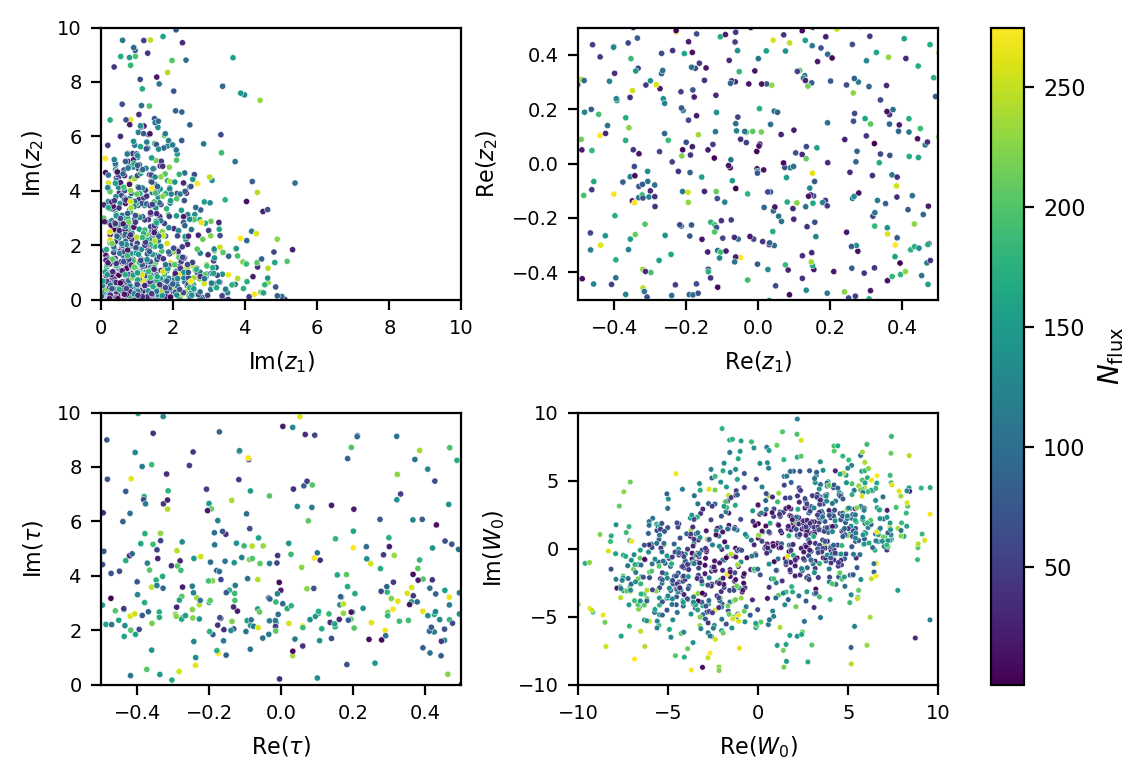

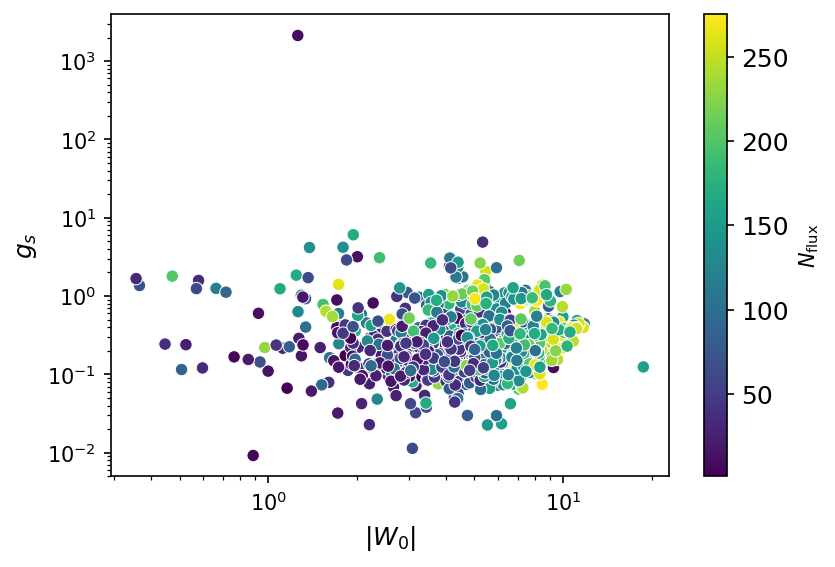

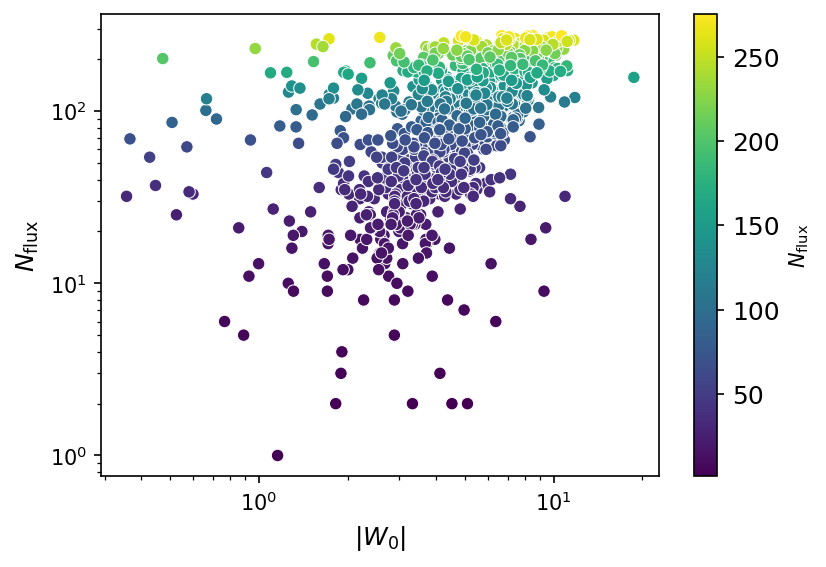

In [15]:
make_overview_plots(model,moduli,tau,fluxes,moduli_range=[[-0.5,0.5],[0,10]],tau_range=[[-0.5,0.5],[0,10]],W0_range=[-10,10])

### Running with multiple optimisers

We can also run the above code with multiple optimisers

In [ ]:
kwargs = {"Q":model.D3_tadpole,"return_flag":True,"constraints": None,"remove_NANs":True,"in_axes":(0,0,0)}

linearised_shifts_ISD = vmapping_func(model.linearised_shifts,mode="ISD",**kwargs)
linearised_shifts_H = vmapping_func(model.linearised_shifts,mode="Hflux",**kwargs)
linearised_shifts_F = vmapping_func(model.linearised_shifts,mode="Fflux",**kwargs)

optimisers = [linearised_shifts_ISD,linearised_shifts_H,linearised_shifts_F]

We can provide a list as `optimisers=optimisers` and run

In [ ]:
moduli,tau,fluxes,residuals = model.sample_SUSY_flux_vacua(N=10**2,
                                                           rns_key=rns_key,
                                                           sampler=sampler,
                                                           optimisers=optimisers,
                                                           objective_fct=DW_v,
                                                           vmap_dim=10**2,
                                                           print_progress=True)

Let us plot the solutions obtained

In [ ]:
make_overview_plots(model,moduli,tau,fluxes,moduli_range=[[-0.5,0.5],[0,10]],tau_range=[[-0.5,0.5],[0,10]],W0_range=[-10,10])

### Old method: uniform sampling of fluxes from box

In many applications, it has been common practice to search for flux vacua by sampling fluxes from a uniform distribution
defined on some hypercube in flux space.
This method can also be employed here by using `mode="random"` as keyword argument when defining the optimiser:

In [ ]:
kwargs = {"Q":model.D3_tadpole,"return_flag":True,"constraints": None,"remove_NANs":True,"in_axes":(0,0,0)}

linearised_shifts = vmapping_func(model.linearised_shifts,mode="random",**kwargs)

We run the same function as above just with a new optimiser

In [ ]:
moduli,tau,fluxes,residuals = model.sample_SUSY_flux_vacua(N=10**3,
                                                           rns_key=rns_key,
                                                           sampler=sampler,
                                                           optimiser=linearised_shifts,
                                                           moduli_sampling_mode="cone",
                                                           objective_fct=DW_v,
                                                           vmap_dim=10**2,
                                                           print_progress=True)

We visualise the solutions here

In [ ]:
make_overview_plots(model,moduli,tau,fluxes,moduli_range=[[-0.5,0.5],[0,5]],tau_range=[[-0.5,0.5],[0,2]],W0_range=[-10,10])

As discussed e.g. in [2306.06160](https://arxiv.org/abs/2306.06160) and [2308.15525](https://arxiv.org/abs/2308.15525),
the resulting distribution of moduli clusters around the boundary of the mirror Kähler cone.
More specifically, since we take the leading order mirror dual worldsheet instanton contributions into account,
the vacua are typically shifted away from the walls of the mirror Kähler cone towards the region of GV convergence.
In practice, we should check whether our solutions are under control by e.g. imposing that the ratio
\begin{equation}
    \dfrac{|F_{\mathrm{inst}}|}{|F_{\mathrm{poly}}|} <\epsilon
\end{equation}
for some $\epsilon\ll 1$. For $\epsilon=0.1$, this is done as follows:

In [ ]:
Finst = jax.vmap(model.F_inst)(moduli)
Fpoly = jax.vmap(model.F_LCS_poly)(moduli)
epsilon = 0.1
flag = np.abs(Finst)/np.abs(Fpoly)<epsilon
moduli_res,tau_res,fluxes_res = moduli[flag],tau[flag],fluxes[flag]
print(f"#vacua: {moduli.shape[0]}  without post-selection")
print(f"#vacua: {moduli_res.shape[0]}  with those vacua outside naive radius of convergence removed  ")

In [ ]:
make_overview_plots(model,moduli_res,tau_res,fluxes_res,moduli_range=[[-0.5,0.5],[0,5]],tau_range=[[-0.5,0.5],[0,2]],W0_range=[-10,10])

### Constrained sampling

There is also the option to include restrictions on the vacua by imposing desired properties.
In many application, it might be desirable for moduli to take values in a certain range
or other quantities like $g_s$, $N_{\mathrm{flux}}$ or $W_0$ to satisfy specific bounds.
Below, we present different two different use cases, but generalisations are straight forward.

Before we start, let us stress that, when making use of ISD sampling, the methods presented below
**are not** just rejection sampling. Instead, as described in [upcoming](upcoming), when momentarily working
with continuous ISD fluxes, various quantities like the moduli VEVs or $W_0$ can be well approximated
**before minimisation**. This allows for a much more efficient way to obtain flux vacua with constraints.

#### Regions of moduli space

Here, as a proof of concept, we would like the moduli to satisfy $2< Im(z^i)<3$ and the axio-dilaton $Im(\tau)>4$.
This is achieved by defining a function that takes as input `moduli,tau,flux` and returns a boolean value:

In [ ]:
@jit
def constraints_model(moduli,tau,flux):
    
    return ((jnp.all(jnp.imag(moduli)<3.,axis=0))&(jnp.all(jnp.imag(moduli)>2.,axis=0))&(jnp.imag(tau)>4))


kwargs = {"Q":model.D3_tadpole,"return_flag":True,"constraints": constraints_model,"remove_NANs":True,"in_axes":(0,0,0)}

linearised_shifts_F_v = vmapping_func(model.linearised_shifts,mode="Fflux",**kwargs)

Let us redefine our sample to accomodate these constraints

In [ ]:
sampler = jaxvacua.data_sampler(model,flux_bounds=[-5,5],moduli_bounds=[2,3],dilaton_bounds=[4,10])

We sample minima by running the following code with `optimiser=linearised_shifts_F_v` and `objective_fct=DW_v`:

In [ ]:
moduli,tau,fluxes,residuals = model.sample_SUSY_flux_vacua(N=10**2,
                                                         rns_key=rns_key,
                                                         sampler=sampler,
                                                         optimiser=linearised_shifts_F_v,
                                                         objective_fct=DW_v,
                                                         vmap_dim=10**2,
                                                         print_progress=True)

In [ ]:
make_overview_plots(model,moduli,tau,fluxes,moduli_range=[[-0.5,0.5],[1,4]],tau_range=[[-0.5,0.5],[3,12]],W0_range=[-10,10])

#### Vacua with small $|W_0|$

Another application concerns finding flux vacua with small $|W_0|$.
The code below implements the algorithm described in [upcoming](upcoming) for general constraints.
The idea is simple: when using ISD sampling for the fluxes, we can momentarily work with continuous fluxes
and estimate values of certain quantities like $|W_0|$ before finding the true $F$-term minimum with quantised fluxes.
This provides in many cases a very good approximation of the true value of said quantity in the actual vacuum.
The advantage is that the expensive minimisation step on uninteresting vacua can be avoided and one simply has to sample
efficiently. **REWRITE**

In practice, this works by providing a refined constraint function `check_constraints`

**THIS IS STILL WORK IN PROGRESS**

In [ ]:
@jit
def check_constraints(moduli,tau,flux):
    
    W0 = model.superpotential_gauge_invariant(moduli,tau,flux)
    
    return (jnp.abs(W0)<0.1)#&(jnp.all(moduli.imag>1,axis=0))

kwargs = {"Q":model.D3_tadpole,"return_flag":True,"constraints":check_constraints,"remove_NANs":True,"in_axes":(0,0,0)}

We define a sampling object

In [ ]:
seed = 42
rns_key = jaxvacua.PRNGSequence(seed)

sampler = jaxvacua.data_sampler(model,flux_bounds=[-3,3],moduli_bounds=[1,3],dilaton_bounds=[1,10])

We define the objective function and the optimisation steps

In [ ]:
DW_v = vmap(model.DW)

linearised_shifts_ISD_v = vmapping_func(model.linearised_shifts,mode="ISD",**kwargs)
linearised_shifts_H_v = vmapping_func(model.linearised_shifts,mode="Hflux",**kwargs)
linearised_shifts_F_v = vmapping_func(model.linearised_shifts,mode="Fflux",**kwargs)
optimisers = [linearised_shifts_ISD_v,linearised_shifts_H_v,linearised_shifts_F_v]

In [ ]:
optimisers = [linearised_shifts_H_v]

In [ ]:
optimisers = [linearised_shifts_F_v]

We then run the same code as above and simply provide the constraint function as follows
`constraints = vmap(check_constraints,in_axes=(0,0,0))`:

In [ ]:
moduli,tau,fluxes,residuals = model.sample_SUSY_flux_vacua(N=10**3,rns_key=rns_key,
                                                           constraints = vmap(check_constraints,in_axes=(0,0,0)),
                                                           moduli_sampling_mode="cone",
                                                           sampler=sampler,
                                                           optimisers=optimisers,
                                                           objective_fct=DW_v,
                                                           vmap_dim=10**2,
                                                           print_progress=True)

Let us plot the final solutions

In [ ]:
make_overview_plots(moduli,tau,fluxes,moduli_range=[[-0.5,0.5],[1,4]],tau_range=[[-0.5,0.5],[3,12]],W0_range=[-10,10])